# Understanding Gradient Boosting: A Step-by-Step Implementation

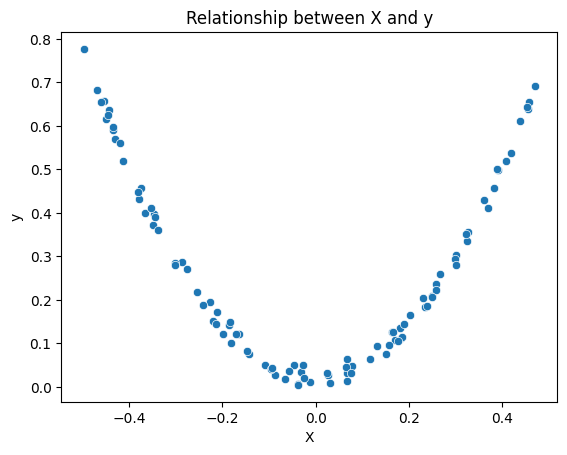

In [4]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Generate synthetic non-linear data (a quadratic curve with noise)
# X: 100 random values between -0.5 and 0.5
X = np.random.rand(100, 1) - 0.5
# y: 3 * X^2 + random noise
y = 3 * X[:, 0]**2 + 0.05 * np.random.rand(100)

# Store in a DataFrame for easier handling
df = pd.DataFrame({'X': X.reshape(100), 'y': y})

# Visualize the underlying relationship we want our model to learn
sns.scatterplot(data=df, x='X', y='y')
plt.title('Relationship between X and y')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

This notebook aims to demystify Gradient Boosting by building a simple regressor from scratch. We will walk through the core concepts: initializing with a base prediction, iteratively training weak learners (decision trees) on the residuals (errors) of the previous predictions, and combining these learners to form a strong predictor.

## Step 1: The Initial Base Prediction (F0)

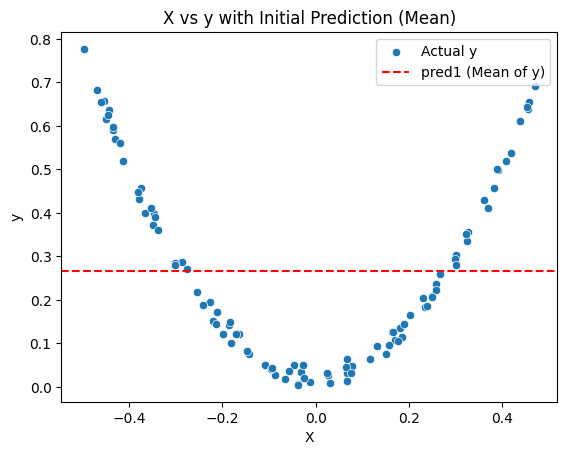

In [5]:
# STEP 1: Initialize the model with a constant value.
# For regression with mean squared error, the optimal constant is the mean of y.
df['pred1'] = df['y'].mean()

# Calculate the initial pseudo-residuals (Actual y - Predicted y)
# This represents what our model currently gets wrong.
df['res1'] = df['y'] - df['pred1']

# Visualize the initial prediction (a flat line at the mean)
sns.scatterplot(data=df, x='X', y='y', label='Actual y')
plt.axhline(y=df['pred1'].iloc[0], color='r', linestyle='--', label='pred1 (Mean of y)')
plt.title('X vs y with Initial Prediction (Mean)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## Step 2: Training the First Weak Learner

We train a decision tree on the initial residuals to capture some of the patterns the base prediction missed. This tree learns to predict the errors, not the actual `y` values.

In [6]:
from sklearn.tree import DecisionTreeRegressor
tree1 = DecisionTreeRegressor(max_leaf_nodes=8)
tree1.fit(df['X'].values.reshape(100,1), df['res1'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

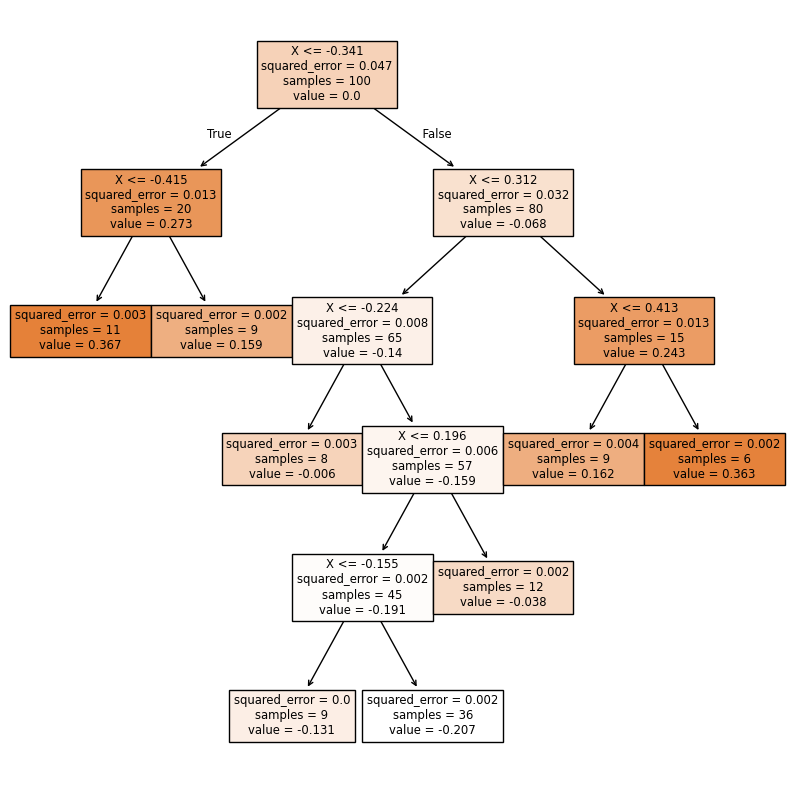

In [7]:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(tree1, filled=True, feature_names=['X'])
plt.show()

In [8]:
X_test = np.linspace(-0.5,0.5,500)
y_pred1 = df['y'].mean() + tree1.predict(X_test.reshape(500,1))

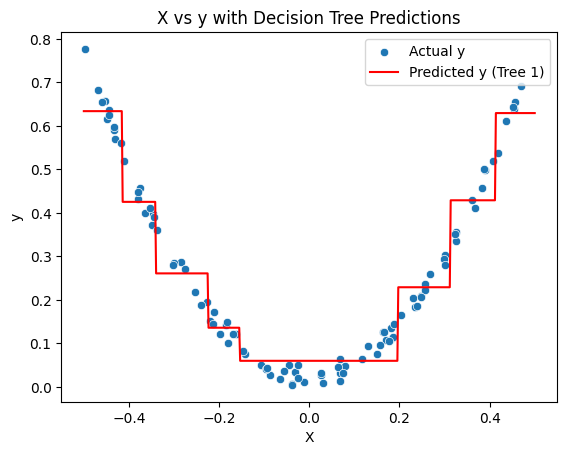

In [9]:
sns.scatterplot(data=df, x='X', y='y', label='Actual y')
plt.plot(X_test, y_pred1, color='r', label='Predicted y (Tree 1)')
plt.title('X vs y with Decision Tree Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## Step 3: Iteration - Training the Second Tree

In [11]:
df['pred2'] = df['y'].mean() + tree1.predict(df['X'].values.reshape(100,1))
df['res2'] = df['y'] - df['pred2']

In [12]:
tree2 = DecisionTreeRegressor(max_leaf_nodes=8)
tree2.fit(df['X'].values.reshape(100,1), df['res2'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [13]:
y_pred2 = df['y'].mean() + sum(regressor.predict(X_test.reshape(-1,1)) for regressor in [tree1, tree2])

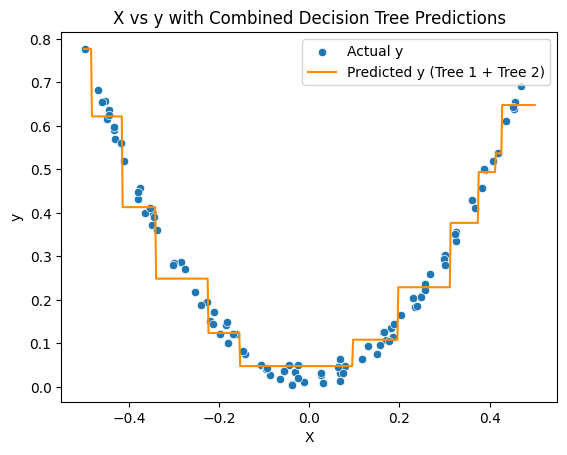

In [14]:
sns.scatterplot(data=df, x='X', y='y', label='Actual y')
plt.plot(X_test, y_pred2, color='darkorange', label='Predicted y (Tree 1 + Tree 2)')
plt.title('X vs y with Combined Decision Tree Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## Step 4: Iteration - Training the Third Tree

In [15]:
df['pred3'] = df['y'].mean() + tree1.predict(df['X'].values.reshape(100,1)) + tree2.predict(df['X'].values.reshape(100,1))
df['res3'] = df['y'] - df['pred3']

In [16]:
tree3 = DecisionTreeRegressor(max_leaf_nodes=8)
tree3.fit(df['X'].values.reshape(100,1), df['res3'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [17]:
y_pred3 = df['y'].mean() + sum(regressor.predict(X_test.reshape(-1,1)) for regressor in [tree1, tree2, tree3])

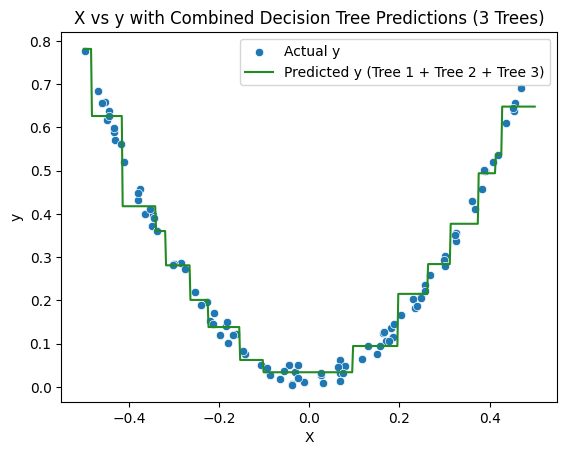

In [18]:
sns.scatterplot(data=df, x='X', y='y', label='Actual y')
plt.plot(X_test, y_pred3, color='forestgreen', label='Predicted y (Tree 1 + Tree 2 + Tree 3)')
plt.title('X vs y with Combined Decision Tree Predictions (3 Trees)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## Step 5: Iteration - Training the Fourth Tree

In [19]:
df['pred4'] = df['y'].mean() + tree1.predict(df['X'].values.reshape(100,1)) + tree2.predict(df['X'].values.reshape(100,1)) + tree3.predict(df['X'].values.reshape(100,1))
df['res4'] = df['y'] - df['pred4']


In [20]:
tree4 = DecisionTreeRegressor(max_leaf_nodes=8)
tree4.fit(df['X'].values.reshape(100,1), df['res4'].values)

DecisionTreeRegressor(max_leaf_nodes=8)

In [21]:
y_pred4 = df['y'].mean() + sum(regressor.predict(X_test.reshape(-1,1)) for regressor in [tree1, tree2, tree3, tree4])

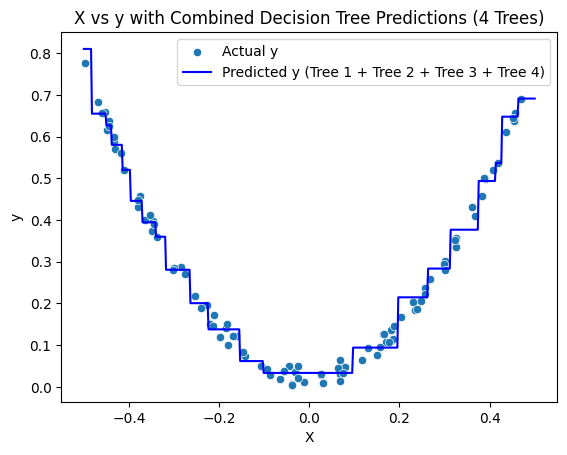

In [22]:
sns.scatterplot(data=df, x='X', y='y', label='Actual y')
plt.plot(X_test, y_pred4, color='blue', label='Predicted y (Tree 1 + Tree 2 + Tree 3 + Tree 4)')
plt.title('X vs y with Combined Decision Tree Predictions (4 Trees)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## Gradient Boost Regresrror from Scratch

In [23]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

class gradient_boost:
  def __init__(self, n_estimators=100, max_depth=3):
    self.n_estimators = n_estimators
    self.max_depth = max_depth
    self.estimators = []
    self.initial_prediction = None

  def fit(self, X, y):
    self.initial_prediction = y.mean()
    current_predictions = np.full_like(y, self.initial_prediction, dtype=float)

    for _ in range(self.n_estimators):
      residuals = y - current_predictions
      tree = DecisionTreeRegressor(max_depth=self.max_depth)
      tree.fit(X, residuals)
      self.estimators.append(tree)
      current_predictions += tree.predict(X)

  def predict(self, X):
    if self.initial_prediction is None:
      raise ValueError("Model has not been fitted yet.")
    y_pred = np.full(X.shape[0], self.initial_prediction, dtype=float)
    for estimator in self.estimators:
      y_pred += estimator.predict(X)
    return y_pred

In [25]:
gb = gradient_boost(n_estimators=5, max_depth=3)
gb.fit(df['X'].values.reshape(100,1), df['y'].values)

In [26]:
X_test = np.linspace(-0.5,0.5,500).reshape(-1,1)
y_pred_gb = gb.predict(X_test)

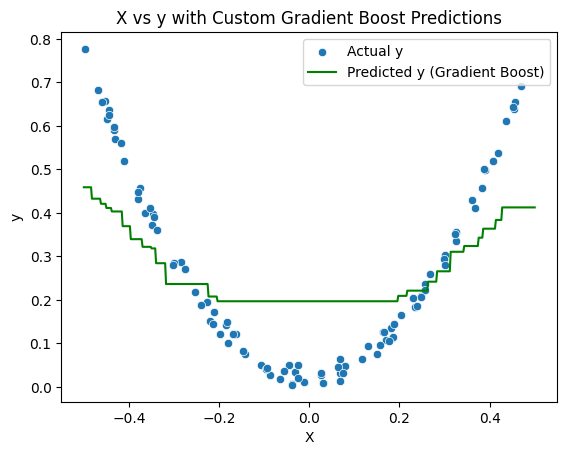

In [27]:
sns.scatterplot(data=df, x='X', y='y', label='Actual y')
plt.plot(X_test, y_pred_gb, color='green', label='Predicted y (Gradient Boost)')
plt.title('X vs y with Custom Gradient Boost Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()